# ML Supervised Algorithms

### Group Work
#### Modeling nonlinear relationships in the California Housing dataset

- construct polynomial features to fit nonlinear relationships in the Housing dataset
- model the relationship between house prices and MedInc as using second degree (quadratic) and third degree (cubic) polynomials and compare it to a linear fit
- plot scatter plot between price and MedInc and add all fits in one plot
- report mean_squared_error, r2_score for all fits
- use simple least sqare error regression



In [1]:
# from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# housing = fetch_california_housing()
# df= pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])
# df

In [ ]:
# load housing dataset (saved on your gdrive - check the Dataset folder on Onedrive)

# First mount google drive to be usable and reachable as data storage in colab
from google.colab import drive
drive.mount('/content/drive')

# define path to file
filename = '/content/drive/MyDrive/Teaching/MLP/2024_spring/Datasets/housing.pkl'

# import pickle package to deal with pkl data
import pickle
with open(filename, 'rb') as bunch:
    housing = pickle.load(bunch)

df= pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])
df

In [ ]:
X = df[['MedInc']].values
print(X)
# X is a 2D array

[[8.3252]
 [8.3014]
 [7.2574]
 ...
 [1.7   ]
 [1.8672]
 [2.3886]]


In [ ]:
X = df['MedInc'].values
print(X)
# X is a 1D array

[8.3252 8.3014 7.2574 ... 1.7    1.8672 2.3886]


In [ ]:
y = df['target'].values
print(y)
# y is 1D Array

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [ ]:
y = df[['target']].values
print(y)
# y is 2D Array

[[4.526]
 [3.585]
 [3.521]
 ...
 [0.923]
 [0.847]
 [0.894]]


In [ ]:
# your code
X = df[['MedInc']].values #because PolynomialFeatures expects as input a 2d array
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html

# another solution is to use the two following lines
# X = df['MedInc'].values # this outputs 1D array
# X = X.reshape(-1, 1) # this reshapes X to 2D array

#applying scalling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
ss = StandardScaler()
X = ss.fit_transform(X)

y = df['target'].values
# create quadratic features
quadratic = PolynomialFeatures(degree=2)
cubic = PolynomialFeatures(degree=3)


X_quad = quadratic.fit_transform(X) # here X must be a 2D array
X_cubic = cubic.fit_transform(X)

# create a new data X_fit on which we will predict
X_fit = np.arange(X.min(), X.max(), 0.1)[:, np.newaxis] # this creates new 2D array consisting of values in range of Xnim to Xmax

# fit features on X and predicts on X_fit
# for linear features
regr = LinearRegression()
regr = regr.fit(X, y)
y_lin_fit = regr.predict(X_fit)
linear_r2 = r2_score(y, regr.predict(X))

# for quadratic features
regr = LinearRegression()
regr = regr.fit(X_quad, y)
# remember here(above) the equation for regression using quadratic features is
# y = w0 + w1*x + w2*x^2
# therefore we need to have a X_quad array shape of (n_sample,3)
y_quad_fit = regr.predict(quadratic.fit_transform(X_fit)) # we need to transform X_fit to quadratic feature set
quadratic_r2 = r2_score(y, regr.predict(X_quad))

# for cubic features
regr = regr.fit(X_cubic, y)
y_cubic_fit = regr.predict(cubic.fit_transform(X_fit))
cubic_r2 = r2_score(y, regr.predict(X_cubic))


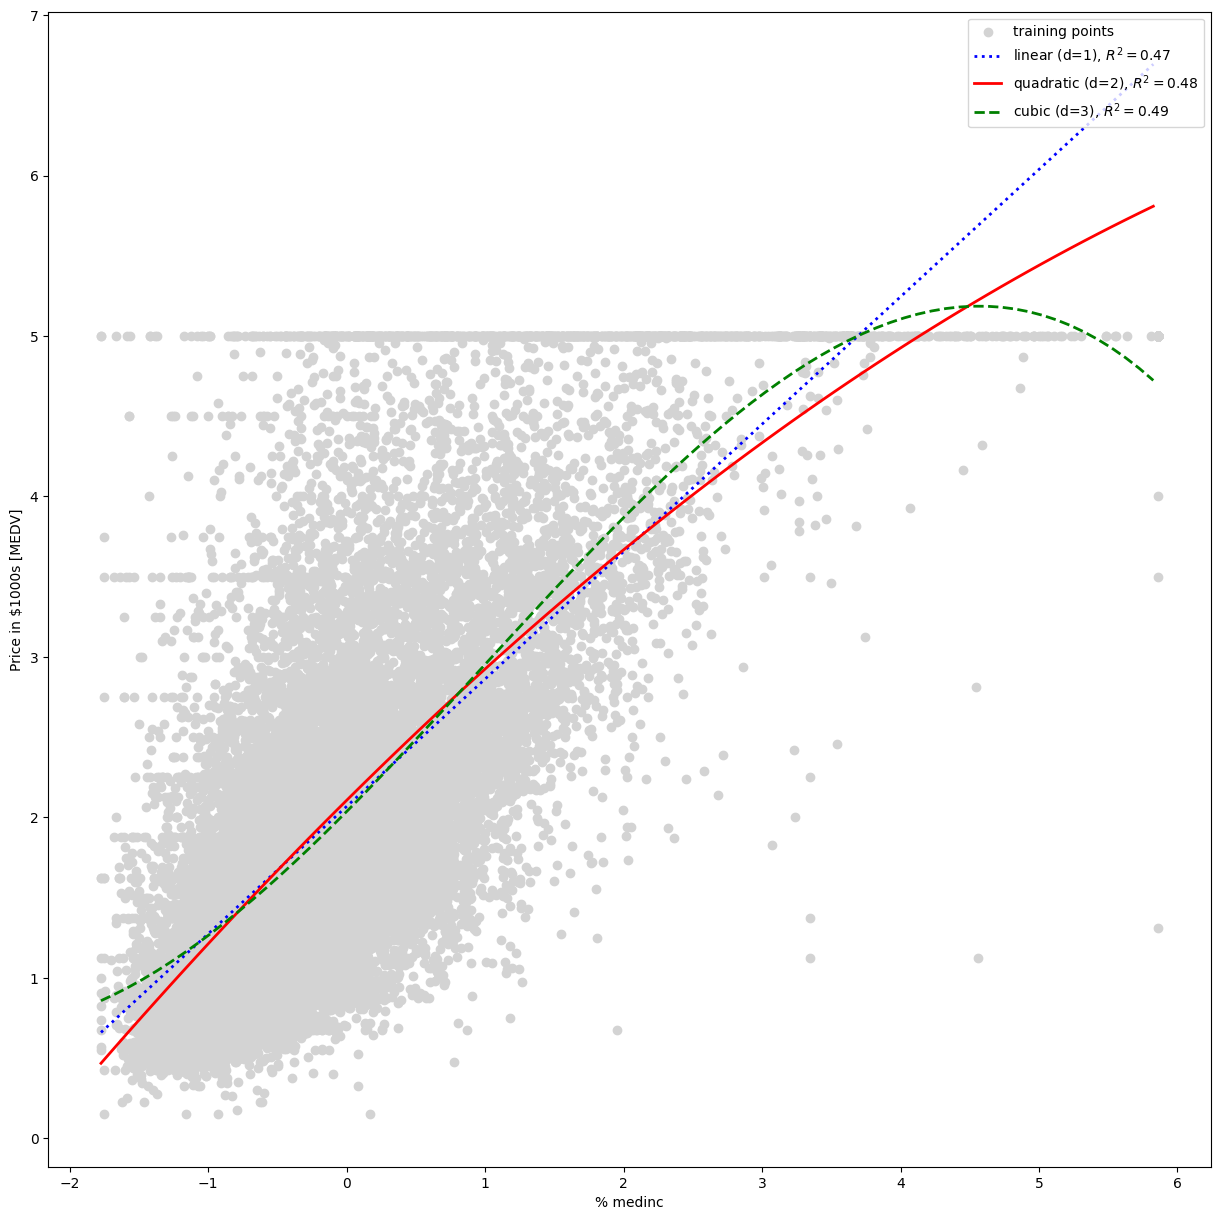

In [ ]:
# plot all- remember if we want to have a unscalled x axis, we need to unscale X values for the plots
fig, ax = plt.subplots(figsize=(15,15))

plt.scatter(X, y, label='training points', color='lightgray')

plt.plot(X_fit, y_lin_fit,
        label='linear (d=1), $R^2=%.2f$' % linear_r2,
        color='blue',
        lw=2,
        linestyle=':')
plt.plot(X_fit, y_quad_fit,
        label='quadratic (d=2), $R^2=%.2f$' % quadratic_r2,
        color='red',
        lw=2,
        linestyle='-')
plt.plot(X_fit, y_cubic_fit,
        label='cubic (d=3), $R^2=%.2f$' % cubic_r2,
        color='green',
        lw=2,
        linestyle='--')

plt.xlabel('% medinc')
plt.ylabel('Price in $1000s [MEDV]')
plt.legend(loc='upper right')


## Homework

### 1
Apply a regression algorithm to selected toy data (housing, diabetes, ...).
You can generate your own dataset with sklearn.datasets.make_regression

Select two different feature sets and compare results.
- Use one of these:
  - sklearn.tree.DecisionTreeRegressor
  - sklearn.ensemble.RandomForestRegressor
  - sklearn.svm.SVR
- pay attention that above models are regression models, decision tree, random forest and support vector machine are used for regression purposes here

- Use feature engineering to generate new features or to drop less significant features


In [ ]:
# your code
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor as DTR
from sklearn.ensemble import RandomForestRegressor as RFR
from sklearn.svm import SVR as SVR

housing = fetch_california_housing()
df= pd.DataFrame(data= np.c_[housing['data'], housing['target']],columns= list(housing['feature_names']) + ['target'])



In [ ]:
# data = df.drop(columns=['target']) # one method to drop last column
data_X = df.iloc[:,:-1].values # another method
data_y = df.iloc[:,-1].values

# .values is used because many following algorithms fitting works with input data in array format and not in pandas dataframe format. It is faster and without warnings ehnw using arrays.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, random_state=10) # stratify preserves the class ratios


In [ ]:
# to see how much data is in training and in testing database
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)
# X_train and X_test variables are Dataframe
# y_train and y_test are series

(15480, 8)
(15480,)
(5160, 8)
(5160,)


In [ ]:
# scaling
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train_scaled = sc_X.fit_transform(X_train)
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1,1))
X_test_scaled = sc_X.transform(X_test) # it is important that test data is not part of scaling of train data
y_test_scaled = sc_y.transform(y_test.reshape(-1,1))

In [ ]:
print(X_train_scaled.shape)
print(y_train_scaled.shape)
print(X_test_scaled.shape)
print(y_test_scaled.shape)

(15480, 8)
(15480, 1)
(5160, 8)
(5160, 1)


In [ ]:
# train DTR
regr = DTR(random_state=10)
regr.fit(X_train_scaled, y_train_scaled)
print("R2 on scaled test set: {:.3f}".format(regr.score(X_test_scaled, y_test_scaled)))
regr.fit(X_train, y_train)
print("R2 on raw test set: {:.3f}".format(regr.score(X_test, y_test)))

R2 on scaled test set: 0.633
R2 on raw test set: 0.632


In [ ]:
# just to see format of different variables
print(y_train)
print(y_test_scaled)
print(y_test_scaled.ravel())

[1.588 2.829 0.621 ... 2.419 1.5   1.911]
[[-0.34115093]
 [ 1.28003474]
 [-0.40367121]
 ...
 [-0.11711991]
 [-0.22739875]
 [ 1.84184895]]
[-0.34115093  1.28003474 -0.40367121 ... -0.11711991 -0.22739875
  1.84184895]


In [ ]:
regr = RFR(random_state=10)
regr.fit(X_train_scaled, y_train_scaled.ravel()) # ravel() method is here to addapt format of y to 1d array
print("R2 on scaled test set: {:.3f}".format(regr.score(X_test_scaled, y_test_scaled)))
regr.fit(X_train, y_train)
print("R2 on raw test set: {:.3f}".format(regr.score(X_test, y_test))) # decision tree based methods do not need scaling, still I recommend it

R2 on scaled test set: 0.806
R2 on raw test set: 0.806


In [ ]:
# regr = SVR(kernel='linear') # uncomment to see results for linear kernel
regr = SVR()
regr.fit(X_train_scaled, y_train_scaled.ravel())
print("R2 on scaled test set: {:.3f}".format(regr.score(X_test_scaled, y_test_scaled)))
regr.fit(X_train, y_train)
print("R2 on test set: {:.3f}".format(regr.score(X_test, y_test))) # see effect of the scaling, results here are very bad

R2 on scaled test set: 0.742
R2 on test set: -0.027


### 2
Apply a classification algorithm to iris data to classify 3 classes of flowers. Use logistic regression, SVC with linear and rbf kernel, KNN, and decision tree Compare results in terms of prediction accuracy within training and testing data

In [ ]:
# your code
# this is essentially the same as in previous task, except using classifiers as used in lecture
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# this is how to mount google drive to be usable and reachable as data storage
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# convert colab nb to html
%%shell
jupyter-nbconvert --to html /content/drive/MyDrive/Teaching/MLP/2023_autumn/W2-Solutions.ipynb


This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    Execute the notebook prior to export.
    Equivalent to: [--ExecutePr

[NbConvertApp] WARNING | pattern '/0_Module/M3_Machine_Learning/Notebooks/W2/W2-Exercises.ipynb' matched no files
